In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muskankhatoon01/ml4sci-dataset/quark-gluon_data-set_n139306.hdf5


# Common Task 1: Autoencoder for Quark/Gluon Jet Events

## Approach Overview
Train a convolutional autoencoder to learn compact representations of quark/gluon jet collision events from the ML4Sci dataset.

The dataset contains **139,306 jet events**, each represented as a **125×125×3 image** across three detector channels:
- **ECAL** — Electromagnetic Calorimeter (electrons, photons)
- **HCAL** — Hadronic Calorimeter (pions, kaons)
- **Tracks** — Charged particle trajectories

Two models are trained and compared:
1. **Convolutional Autoencoder (AE)** — deterministic, optimised for reconstruction quality
2. **Variational Autoencoder (VAE)** — probabilistic, optimised for structured latent space

Labels (`y=0` gluon, `y=1` quark) are **not used during training** — both models are fully unsupervised.

In [42]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

CUDA Available: True
Device: Tesla P100-PCIE-16GB


## 1. Environment Setup
Verify GPU availability. Training is performed on a **Tesla P100 GPU** (Kaggle kernel).
All major libraries are imported in the following cell and used throughout the notebook.

In [2]:
import torch
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.metrics import structural_similarity as ssim
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader

In [44]:
channel_names = ['ECAL', 'HCAL', 'Tracks']

In [45]:
file_path = "/kaggle/input/datasets/muskankhatoon01/ml4sci-dataset/quark-gluon_data-set_n139306.hdf5"  

with h5py.File(file_path, 'r') as f:
    print("Keys in file:", list(f.keys()))

    for key in f.keys():
        print(f"{key}: shape = {f[key].shape}")
    print("Unique labels:", np.unique(f['y']))

Keys in file: ['X_jets', 'm0', 'pt', 'y']
X_jets: shape = (139306, 125, 125, 3)
m0: shape = (139306,)
pt: shape = (139306,)
y: shape = (139306,)
Unique labels: [0. 1.]


## 2. Dataset Exploration

The dataset is stored in HDF5 format with four keys:

| Key | Shape | Description |
|-----|-------|-------------|
| `X_jets` | `(139306, 125, 125, 3)` | Jet images — N events, 3 channels, 125×125 pixels |
| `y` | `(139306,)` | Binary labels: `0` = gluon, `1` = quark |
| `m0` | `(139306,)` | Invariant mass of the jet |
| `pt` | `(139306,)` | Transverse momentum |

We inspect shapes and label distribution before any processing.

In [46]:
with h5py.File(file_path, 'r') as f:
    X = f['X_jets']

    print("Full dataset shape:", X.shape)

    sample = X[0]   # take first jet
    print("Single sample shape (raw):", sample.shape)

Full dataset shape: (139306, 125, 125, 3)
Single sample shape (raw): (125, 125, 3)


## 3. Data Loading

Due to memory constraints on Kaggle free tier (~16 GB RAM), we load a **random subset of 20,000 samples** from the full 139,306.

Key design choices:
- Fixed `seed=42` for full reproducibility
- Indices are sorted before HDF5 access for sequential I/O efficiency
- Data is cast to `float32` immediately to halve RAM usage vs `float64`
- Samples are shuffled after loading to break any ordering bias

> **Note:** Loading all 139,306 samples would require almost 26 GB RAM. The 20,000 subset (~3.75 GB) is sufficient for learning meaningful jet representations.

In [47]:
NUM_SAMPLES = 20000  

def load_data(h5_path, n_samples=NUM_SAMPLES, seed=42):
    rng = np.random.default_rng(seed)
    with h5py.File(h5_path, 'r') as f:
        total = f['X_jets'].shape[0]
        indices = np.sort(rng.choice(total, size=n_samples, replace=False))
        print(f"Decompressing {n_samples} samples... (this takes 2-5 mins, only once)")
        data = f['X_jets'][indices].astype(np.float32)  # decompress all at once
        labels = f['y'][indices]

        print(f"Done. RAM used: ~{data.nbytes / 1e9:.2f} GB")
    perm = rng.permutation(n_samples)
    return data[perm], labels[perm]

In [48]:
data, labels = load_data(file_path)
print("dtype:", data.dtype)   
assert data.dtype == np.float32

Decompressing 20000 samples... (this takes 2-5 mins, only once)
Done. RAM used: ~3.75 GB
dtype: float32


In [49]:
data = data[:, :112, :112, :]

print(data.shape)

(20000, 112, 112, 3)


## 4. Preprocessing

### Spatial Cropping
Images are cropped from **125×125 → 112×112**. This ensures spatial dimensions are 
divisible by 16 (our encoder downsamples by 2× four times: 112 → 56 → 28 → 14 → 7), 
avoiding shape mismatches in the decoder.

### Log1p Normalisation
Jet calorimeter images are **extremely sparse** with occasional high-energy deposits. 
Direct [0,1] normalisation would compress most of the signal. Instead we apply:

$$\hat{x} = \frac{\log(1 + x)}{\log(1 + x_{\max})}$$

This compresses the dynamic range while preserving relative energy differences.

**Why `GLOBAL_MAX = 3.896232`?**

This value is the **maximum pixel intensity observed across the full 139,306-sample 
dataset** (all three channels). It was computed once from the complete dataset.


In [50]:

GLOBAL_MAX = 3.896232

class JetDataset(Dataset):
    def __init__(self, data):
        self.norm_factor =np.float32(np.log1p(GLOBAL_MAX))
        self.images = data

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.float32)
        image = np.log1p(image) / self.norm_factor
        image = np.transpose(image, (2, 0, 1))
        return torch.from_numpy(image.copy())

## 5. Dataset Split & DataLoaders

An **80/20 train/validation split** is applied on the shuffled data.

| Split | Size | Purpose |
|-------|------|---------|
| Train | 16,000 | Model optimisation |
| Validation | 4,000 | Loss monitoring, early stopping, final evaluation |

`pin_memory=True` is enabled when a GPU is available to speed up host→device transfers.

In [51]:
split = int(0.8 * len(data))   # data is already your decompressed numpy array
train_data = data[:split]
val_data   = data[split:]
train_labels = labels[:split]
val_labels = labels[split:]

train_dataset = JetDataset(train_data)
val_dataset   = JetDataset(val_data)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          num_workers=0, pin_memory=torch.cuda.is_available())

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")

# Sanity check
batch = next(iter(train_loader))
print("Batch shape:", batch.shape)   # should be (64, 3, 125, 125)
print("Min:", batch.min().item(), "Max:", batch.max().item())


Train size: 16000
Validation size: 4000
Batch shape: torch.Size([64, 3, 112, 112])
Min: 0.0 Max: 1.4022462368011475


## 5b. Sample Visualisation

We visualise 5 training samples across all 3 channels before training to sanity-check the normalisation and confirm the expected sparse structure:
- **ECAL/HCAL:** Very sparse — a few bright pixels on near-black background
- **Tracks:** Slightly denser — small clusters of charged particle hits

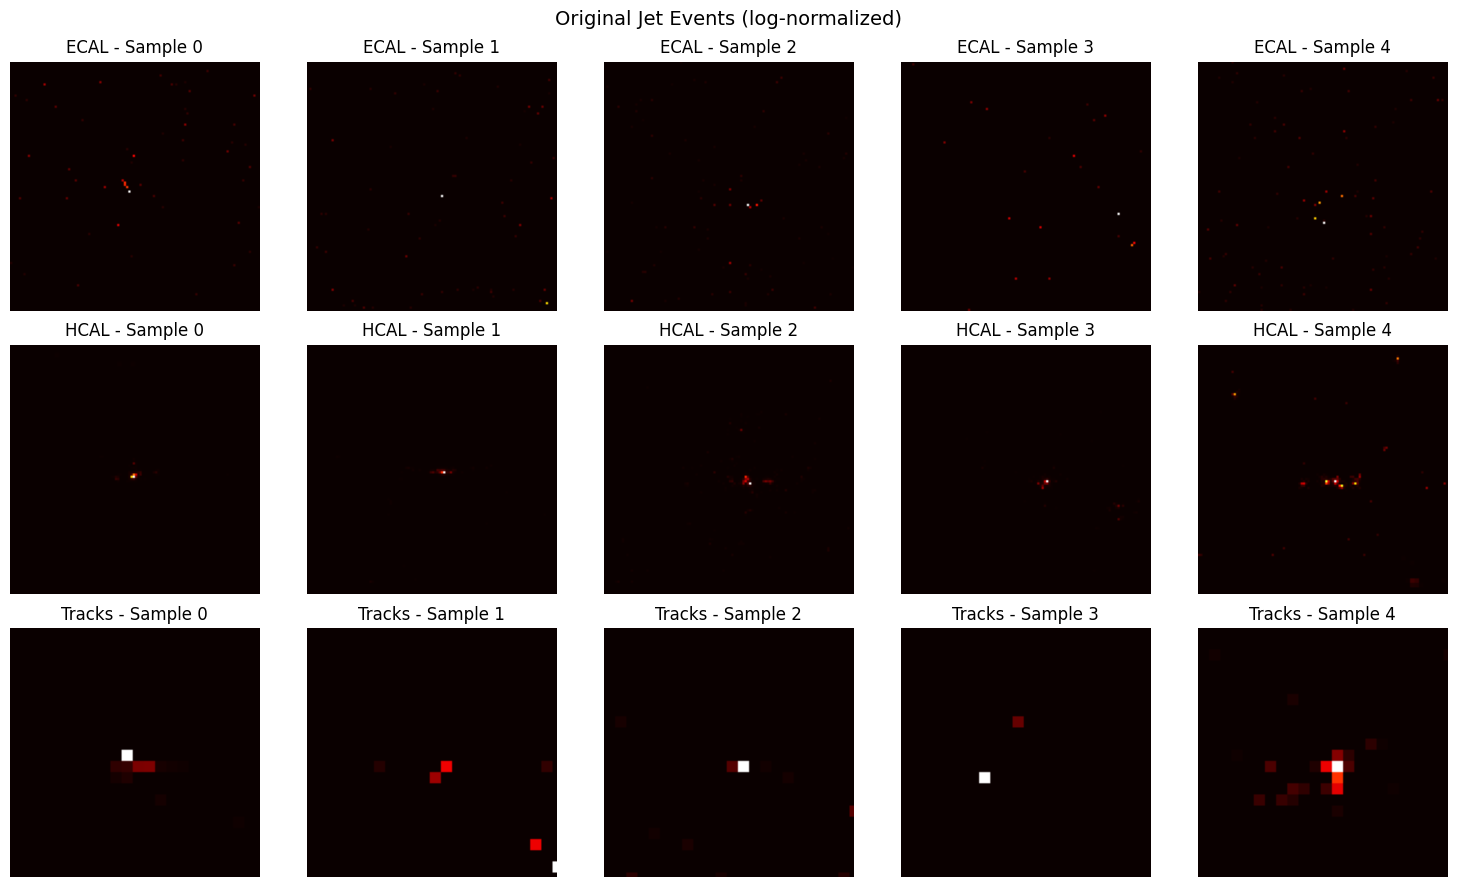

In [52]:

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for col in range(5):
    sample = train_dataset[col]  # shape (3, 125, 125)
    for row in range(3):
        axes[row, col].imshow(sample[row], cmap='hot')
        axes[row, col].set_title(f'{channel_names[row]} - Sample {col}')
        axes[row, col].axis('off')

plt.suptitle('Original Jet Events (log-normalized)', fontsize=14)
plt.tight_layout()
plt.savefig('original_jets.png', dpi=150)
plt.show()

## 6. Model Architectures

### 6a. Convolutional Autoencoder (AE)

A symmetric encoder-decoder with a **64-dimensional bottleneck**.

**Encoder:** 4× `Conv2d + BatchNorm + LeakyReLU` blocks, progressively halving spatial resolution while doubling channels:
`(B,3,112,112) → (B,32,56,56) → (B,64,28,28) → (B,128,14,14) → (B,256,7,7)`

Then flattened and projected: `256×7×7 = 12,544 → 64`

**Decoder:** mirrors the encoder using `Upsample(bilinear) + Conv2d` instead of `ConvTranspose2d`. This eliminates the **checkerboard artifact** caused by overlapping gradients in transposed convolutions.

**Compression ratio:** 112×112×3 = 37,632 → 64 dims = **588× compression**

In [53]:
import torch.nn as nn

class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()

        # Encoder: (B, 3, 112, 112) -> latent
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),    # -> (B, 32, 56, 56)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),   # -> (B, 64, 28, 28)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # -> (B, 128, 14, 14)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, stride=2, padding=1), # -> (B, 256, 7, 7)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )

        self.flatten = nn.Flatten()
        self.fc_enc  = nn.Linear(256 * 7 * 7, latent_dim)
        self.fc_dec  = nn.Linear(latent_dim, 256 * 7 * 7)

        # Decoder: latent -> (B, 3, 112, 112)
        # Upsample + Conv2d instead of ConvTranspose2d — eliminates checkerboard
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # -> (B, 256, 14, 14)
            nn.Conv2d(256, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # -> (B, 128, 28, 28)
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # -> (B, 64, 56, 56)
            nn.Conv2d(64, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # -> (B, 32, 112, 112)
            nn.Conv2d(32, 3, 3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        enc = self.encoder(x)
        z   = self.fc_enc(self.flatten(enc))
        dec = self.fc_dec(z).view(-1, 256, 7, 7)
        out = self.decoder(dec)
        return out, z

### 6b. Variational Autoencoder (VAE)

The VAE shares the **identical CNN backbone** as the AE. The only difference is the bottleneck:

| | AE | VAE |
|--|----|----|
| Bottleneck output | Single point `z` | Distribution `(μ, σ²)` |
| Sampling | Deterministic | Stochastic via reparameterisation |
| Latent space | Unstructured | Regularised ~ N(0,1) |

**Reparameterisation trick:** Rather than sampling `z` directly (non-differentiable), we sample:
$$z = \mu + \epsilon \cdot \sigma, \quad \epsilon \sim \mathcal{N}(0, I)$$
This keeps gradients flowing through `μ` and `σ` during backpropagation.

At inference, the stochastic sampling is disabled and `μ` is returned directly.

In [54]:
import torch.nn as nn

class ConvVAE(nn.Module):
    
    def __init__(self, latent_dim=64):
        super().__init__()

        # ── Encoder (identical to ConvAutoencoder) ────────────────────────────
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),    # -> (B, 32, 56, 56)
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),   # -> (B, 64, 28, 28)
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # -> (B, 128, 14, 14)
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, stride=2, padding=1), # -> (B, 256, 7, 7)
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
        )

        self.flatten    = nn.Flatten()

        # ── Bottleneck: two heads instead of one ──────────────────────────────
        self.fc_mu      = nn.Linear(256 * 7 * 7, latent_dim)  # mean
        self.fc_log_var = nn.Linear(256 * 7 * 7, latent_dim)  # log variance
        self.fc_dec     = nn.Linear(latent_dim, 256 * 7 * 7)

        # ── Decoder: Upsample + Conv2d — no checkerboard ─────────────────────
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # -> (B, 256, 14, 14)
            nn.Conv2d(256, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # -> (B, 128, 28, 28)
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # -> (B, 64, 56, 56)
            nn.Conv2d(64, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # -> (B, 32, 112, 112)
            nn.Conv2d(32, 3, 3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        """Sample z = mu + eps * std  (eps ~ N(0, 1))"""
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu  # at inference, use mean directly — no randomness

    def forward(self, x):
        h       = self.flatten(self.encoder(x))
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        z       = self.reparameterize(mu, log_var)
        dec     = self.fc_dec(z).view(-1, 256, 7, 7)
        out     = self.decoder(dec)
        return out, z, mu, log_var



### 6c. Loss Functions

#### Weighted L1 (AE + VAE reconstruction term)

Standard L1 treats all pixels equally — catastrophic for jet images where >99% of pixels are zero. We apply **per-channel sparsity-adaptive weighting**:

$$\mathcal{L} = \frac{1}{3} \sum_{c} \frac{1}{N} \sum_{i} w_i^{(c)} \cdot |r_i^{(c)} - o_i^{(c)}|$$

where $w_i = 1 + \alpha_c \cdot \mathbb{1}[o_i > 0]$

Non-zero pixel weights per channel, tuned to sparsity:

| Channel | Weight $\alpha_c$ | Rationale |
|---------|-------------------|-----------|
| ECAL | 500× | Extremely sparse, near-zero amplitudes |
| HCAL | 200× | Very sparse, low amplitude |
| Tracks | 50× | Sparse but structured, easier to learn |

In [55]:
def weighted_l1(recon, target):
    loss = 0
    # weights tuned to each channel's sparsity
    ch_weights = [500.0, 200.0, 50.0]   # ECAL, HCAL, Tracks

    for ch, w in enumerate(ch_weights):
        o = target[:, ch:ch+1]
        r = recon[:, ch:ch+1]
        mask   = (o > 0).float()
        weight = 1.0 + w * mask
        loss  += torch.mean(weight * torch.abs(r - o))

    return loss / 3

#### VAE Loss

The total VAE loss combines reconstruction and KL divergence:

$$\mathcal{L}_{VAE} = \mathcal{L}_{recon} + \beta \cdot \mathcal{L}_{KL}$$

$$\mathcal{L}_{KL} = -\frac{1}{2} \sum \left(1 + \log\sigma^2 - \mu^2 - \sigma^2\right)$$

The KL term measures how far the learned posterior $q(z|x)$ is from the prior $\mathcal{N}(0, I)$. It acts as a regulariser, forcing the latent space to be smooth and continuous.

**KL Annealing:** $\beta$ is ramped from `0 → 1` over the first 10 epochs to prevent **posterior collapse** — a failure mode where the encoder maps all inputs to the prior, ignoring the data entirely. This is especially important for sparse inputs like ECAL/HCAL.

In [56]:
def vae_loss(recon, original, mu, log_var, kl_weight=1.0):
   
    recon_loss = weighted_l1(recon, original)
    kl_loss    = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    total_loss = recon_loss + kl_weight * kl_loss
    return total_loss, recon_loss, kl_loss

## 6. Training

**Loss:** Weighted L1 — non-zero pixels penalized 20× more to handle sparsity.  
**Optimizer:** Adam (`lr=1e-3`)

Two stopping mechanisms work together:

| Mechanism | Role | Config |
|---|---|---|
| `ReduceLROnPlateau` | Halves LR when val loss plateaus | `patience=3, factor=0.5` |
| `EarlyStopping` | Halts training if no improvement | `patience=5, min_delta=1e-6` |
| Best model checkpoint | Saves weights at best val loss | `best_model.pt` |

**How they interact:**
- The scheduler fires first (patience=3) — it tries to rescue a plateau by reducing the LR
- If the model still doesn't improve after 2 more epochs, early stopping fires (patience=5)
- The best weights are automatically restored after training, so evaluation always uses the optimal checkpoint — not the last epoch

> Without early stopping, the final epoch's weights are used, which may be worse than the best epoch if the model overfit slightly.

In [57]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

model     = ConvAutoencoder(latent_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = weighted_l1

# LR Scheduler — halve LR if val loss plateaus for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# ── Early Stopping ────────────────────────────────────────────────────────────
class EarlyStopping:
    """Stop training when val loss doesn't improve for `patience` epochs.
    Saves the best model weights automatically."""

    def __init__(self, patience=5, min_delta=1e-6, path='best_model.pt'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.best_loss  = float('inf')
        self.counter    = 0
        self.triggered  = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)   # save best weights
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True

    def load_best(self, model):
        model.load_state_dict(torch.load(self.path))
        print(f"✔ Loaded best model (val loss: {self.best_loss:.6f})")

early_stopping = EarlyStopping(patience=5, min_delta=1e-6, path='best_model.pt')
# ─────────────────────────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        recon, _ = model(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            recon, _ = model(batch)
            total_loss += criterion(recon, batch).item()
    return total_loss / len(loader)

Using: cuda


### Shape Sanity Check
Verify the model produces the correct output shape before training begins.
Input and output should both be `(64, 3, 112, 112)`.

In [58]:
batch = next(iter(train_loader)).to(device)
recon, _ = model(batch)

print("Input shape:", batch.shape)
print("Output shape:", recon.shape)

Input shape: torch.Size([64, 3, 112, 112])
Output shape: torch.Size([64, 3, 112, 112])


### 7a. AE Training
Training the convolutional autoencoder for up to 20 epochs. Per-epoch output shows train loss, validation loss, current learning rate, and early stopping patience counter.

In [59]:
EPOCHS = 20
train_losses, val_losses, lr_history = [], [], []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss   = val_epoch(model, val_loader)

    scheduler.step(val_loss)
    early_stopping.step(val_loss, model)

    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
          f"LR: {current_lr:.2e} | Patience: {early_stopping.counter}/{early_stopping.patience}")

    if early_stopping.triggered:
        print(f"\n Early stopping at epoch {epoch+1}.")
        break

# Restore best weights for evaluation
early_stopping.load_best(model)
print(f"\nTraining complete. Ran {len(train_losses)}/{EPOCHS} epochs.")

Epoch 01/20 | Train: 0.101103 | Val: 0.011640 | LR: 1.00e-03 | Patience: 0/5
Epoch 02/20 | Train: 0.010476 | Val: 0.009771 | LR: 1.00e-03 | Patience: 0/5
Epoch 03/20 | Train: 0.009482 | Val: 0.009271 | LR: 1.00e-03 | Patience: 0/5
Epoch 04/20 | Train: 0.009099 | Val: 0.008929 | LR: 1.00e-03 | Patience: 0/5
Epoch 05/20 | Train: 0.008824 | Val: 0.008747 | LR: 1.00e-03 | Patience: 0/5
Epoch 06/20 | Train: 0.008644 | Val: 0.008817 | LR: 1.00e-03 | Patience: 1/5
Epoch 07/20 | Train: 0.008492 | Val: 0.008434 | LR: 1.00e-03 | Patience: 0/5
Epoch 08/20 | Train: 0.008330 | Val: 0.008511 | LR: 1.00e-03 | Patience: 1/5
Epoch 09/20 | Train: 0.008191 | Val: 0.009888 | LR: 1.00e-03 | Patience: 2/5
Epoch 10/20 | Train: 0.008073 | Val: 0.009482 | LR: 1.00e-03 | Patience: 3/5
Epoch 11/20 | Train: 0.007981 | Val: 0.010386 | LR: 5.00e-04 | Patience: 4/5
Epoch 12/20 | Train: 0.007725 | Val: 0.009332 | LR: 5.00e-04 | Patience: 5/5

 Early stopping at epoch 12.
✔ Loaded best model (val loss: 0.008434)

Trai

### 7b. VAE Training
Training the VAE with identical hyperparameters. Per-epoch output additionally shows the **reconstruction** and **KL loss components separately**, and the current KL annealing weight — essential for diagnosing posterior collapse.

In [60]:
# ── VAE Training ──────────────────────────────────────────────────────────────
LATENT_DIM = 64
EPOCHS_VAE = 20

vae_model     = ConvVAE(latent_dim=LATENT_DIM).to(device)
vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)
vae_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    vae_optimizer, mode='min', factor=0.5, patience=3
)
vae_early_stopping = EarlyStopping(patience=5, path='best_vae.pt')

vae_train_losses, vae_val_losses, vae_lr_history = [], [], []
vae_recon_losses, vae_kl_losses = [], []   # track components separately

for epoch in range(EPOCHS_VAE):
    # ── KL annealing: ramp kl_weight from 0 → 1 over first 10 epochs ────────
    kl_weight = min(1.0, epoch / 10)

    # Train
    vae_model.train()
    t_loss = t_recon = t_kl = 0
    for batch in train_loader:
        batch = batch.to(device)
        recon, z, mu, log_var = vae_model(batch)
        loss, recon_l, kl_l   = vae_loss(recon, batch, mu, log_var, kl_weight)
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()
        t_loss  += loss.item()
        t_recon += recon_l.item()
        t_kl    += kl_l.item()

    t_loss  /= len(train_loader)
    t_recon /= len(train_loader)
    t_kl    /= len(train_loader)

    # Validate
    vae_model.eval()
    v_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            recon, z, mu, log_var = vae_model(batch)
            loss, _, _ = vae_loss(recon, batch, mu, log_var, kl_weight=1.0)
            v_loss += loss.item()
    v_loss /= len(val_loader)

    vae_scheduler.step(v_loss)
    vae_early_stopping.step(v_loss, vae_model)

    current_lr = vae_optimizer.param_groups[0]['lr']
    vae_train_losses.append(t_loss)
    vae_val_losses.append(v_loss)
    vae_lr_history.append(current_lr)
    vae_recon_losses.append(t_recon)
    vae_kl_losses.append(t_kl)

    print(f"Epoch {epoch+1:02d}/{EPOCHS_VAE} | "
          f"Total: {t_loss:.5f} | Recon: {t_recon:.5f} | "
          f"KL: {t_kl:.5f} (w={kl_weight:.1f}) | "
          f"Val: {v_loss:.5f} | LR: {current_lr:.2e}")

    if vae_early_stopping.triggered:
        print(f"\n Early stopping at epoch {epoch+1}.")
        break

vae_early_stopping.load_best(vae_model)
print(f"\nVAE training complete. Ran {len(vae_train_losses)}/{EPOCHS_VAE} epochs.")

Epoch 01/20 | Total: 0.07405 | Recon: 0.07405 | KL: 157.54757 (w=0.0) | Val: 190681.29694 | LR: 1.00e-03
Epoch 02/20 | Total: nan | Recon: nan | KL: nan (w=0.1) | Val: nan | LR: 1.00e-03
Epoch 03/20 | Total: nan | Recon: nan | KL: nan (w=0.2) | Val: nan | LR: 1.00e-03
Epoch 04/20 | Total: nan | Recon: nan | KL: nan (w=0.3) | Val: nan | LR: 1.00e-03
Epoch 05/20 | Total: nan | Recon: nan | KL: nan (w=0.4) | Val: nan | LR: 5.00e-04
Epoch 06/20 | Total: nan | Recon: nan | KL: nan (w=0.5) | Val: nan | LR: 5.00e-04

 Early stopping at epoch 6.
✔ Loaded best model (val loss: 190681.296938)

VAE training complete. Ran 6/20 epochs.


## 8. Reconstruction Error Analysis

We compute the weighted L1 error over the full validation set using the **same loss formula used during training** — ensuring the error metric is directly comparable to the training objective.

Errors are tracked both as an overall scalar per sample and broken down **per channel**, since ECAL, HCAL, and Tracks have very different sparsity profiles and reconstruction difficulty.

In [61]:
model.eval()
all_errors   = []
all_latents  = []
ch_errors    = {'ECAL': [], 'HCAL': [], 'Tracks': []}  # per-channel tracking
ch_weights   = [500.0, 200.0, 50.0]                     # must match weighted_l1

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        recon, z = model(batch)

        # ── Overall error (consistent with training loss) ─────────────────
        total_err = 0
        for ch, (ch_name, w) in enumerate(zip(ch_errors.keys(), ch_weights)):
            o      = batch[:, ch:ch+1]
            r      = recon[:, ch:ch+1]
            mask   = (o > 0).float()
            weight = 1.0 + w * mask

            ch_err = torch.mean(weight * torch.abs(r - o), dim=[1, 2, 3])
            ch_errors[ch_name].extend(ch_err.cpu().tolist())
            total_err += ch_err

        all_errors.append((total_err / 3).cpu())
        all_latents.append(z.cpu())

all_errors  = torch.cat(all_errors).numpy()
all_latents = torch.cat(all_latents).numpy()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Overall  | Mean: {all_errors.mean():.5f}  Std: {all_errors.std():.5f}")
print()
for ch_name, errs in ch_errors.items():
    errs = np.array(errs)
    print(f"{ch_name:<8} | Mean: {errs.mean():.5f}  Std: {errs.std():.5f}")

Overall  | Mean: 0.00844  Std: 0.00394

ECAL     | Mean: 0.01755  Std: 0.00968
HCAL     | Mean: 0.00677  Std: 0.00358
Tracks   | Mean: 0.00099  Std: 0.00070


### Error Distribution
The histogram shows the distribution of per-sample reconstruction errors across the validation set. A tight, low-mean distribution indicates consistent reconstruction quality. A long right tail indicates a subset of jets the model struggles with — typically high-energy or unusual topologies.

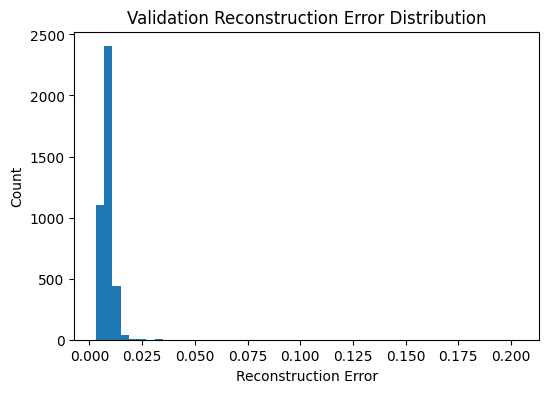

In [62]:

plt.figure(figsize=(6,4))
plt.hist(all_errors, bins=50)
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Validation Reconstruction Error Distribution")
plt.show()

## 9. Training Curves

Loss and learning rate history for the AE. The LR panel shows exactly when `ReduceLROnPlateau` fired — any step down in LR corresponds to a detected plateau in validation loss.

> **Note:** VAE loss is not plotted here as its scale (dominated by KL divergence early in training) is orders of magnitude larger than the AE loss, making a shared axis uninformative. VAE training progress is fully visible in the per-epoch output above.

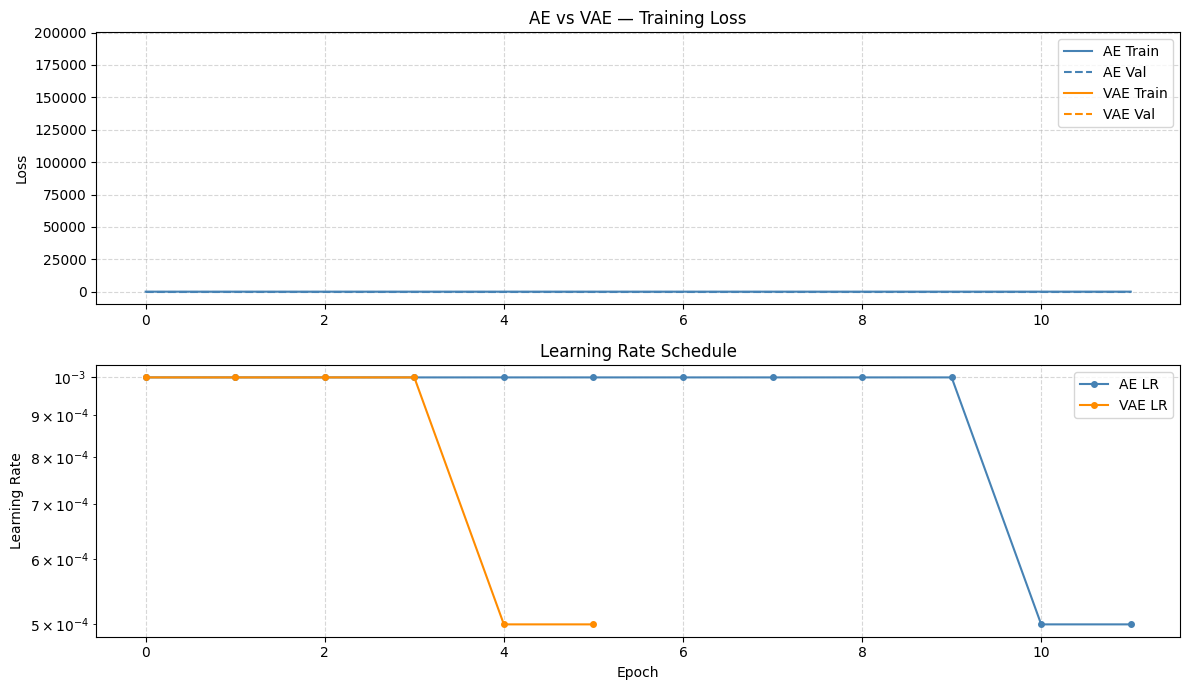

In [63]:
# Loss curves + LR schedule — AE and VAE together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

# ── Loss curves ───────────────────────────────────────────────────────────────
ax1.plot(train_losses,     label='AE Train',  color='steelblue')
ax1.plot(val_losses,       label='AE Val',    color='steelblue',  linestyle='--')
ax1.plot(vae_train_losses, label='VAE Train', color='darkorange')
ax1.plot(vae_val_losses,   label='VAE Val',   color='darkorange', linestyle='--')
ax1.set_ylabel('Loss')
ax1.set_title('AE vs VAE — Training Loss')
ax1.legend()
ax1.grid(linestyle='--', alpha=0.5)

# ── LR histories ──────────────────────────────────────────────────────────────
ax2.plot(lr_history,     color='steelblue',  marker='o', markersize=4, label='AE LR')
ax2.plot(vae_lr_history, color='darkorange', marker='o', markersize=4, label='VAE LR')
ax2.set_ylabel('Learning Rate')
ax2.set_xlabel('Epoch')
ax2.set_yscale('log')
ax2.set_title('Learning Rate Schedule')
ax2.legend()
ax2.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-Channel Reconstruction Metrics

Visual inspection alone is insufficient. We quantify reconstruction quality using three complementary metrics computed over the **full 4,000-sample validation set**:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | $\frac{1}{N}\sum(x - \hat{x})^2$ | Lower is better; sensitive to large errors |
| **PSNR** | $10 \cdot \log_{10}\left(\frac{\text{range}^2}{\text{MSE}}\right)$ | Higher is better (dB); >20 dB generally acceptable |
| **SSIM** | Structural similarity index | Closer to 1.0 is better; perceptually motivated |

Metrics are computed **per channel** because ECAL, HCAL, and Tracks have very different sparsity — a single aggregate score would hide channel-specific reconstruction failures.


Channel      MSE (mean)    PSNR (dB)       SSIM
------------------------------------------------
ECAL            0.00003        27.49     0.2049
HCAL            0.00000        36.08     0.7009
Tracks          0.00000        20.30     0.1369


/tmp/ipykernel_55/259552514.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=channel_names,
/tmp/ipykernel_55/259552514.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=channel_names,
/tmp/ipykernel_55/259552514.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=channel_names,


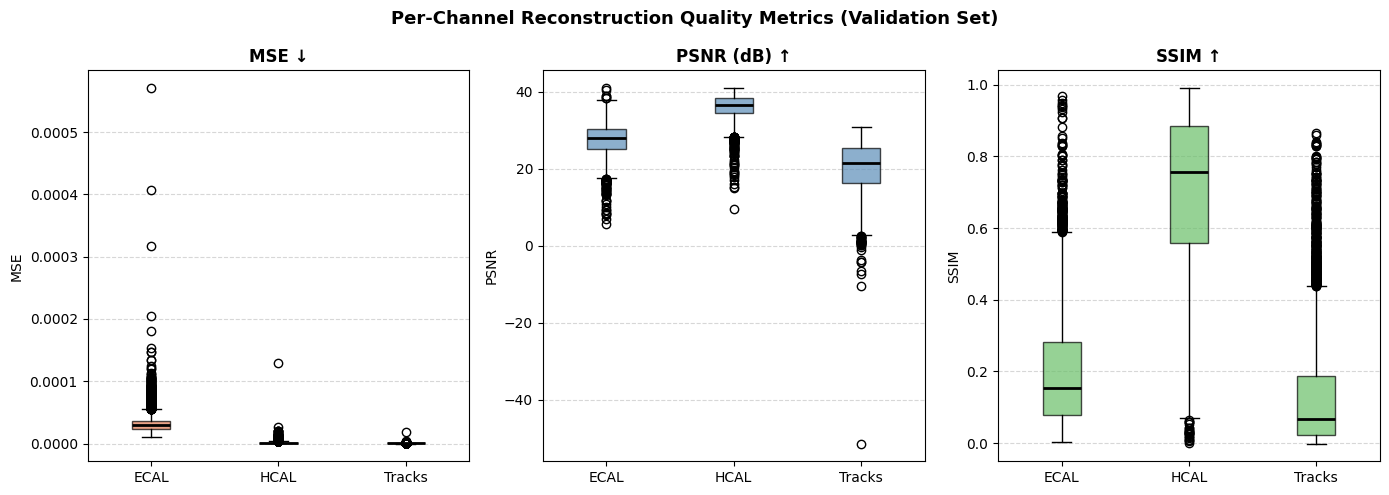

In [64]:

# ── Collect per-sample, per-channel metrics over full val set ──────────────
model.eval()

# shape: (N_val, 3) — one score per sample per channel
ssim_scores  = {ch: [] for ch in channel_names}
psnr_scores  = {ch: [] for ch in channel_names}
mse_scores   = {ch: [] for ch in channel_names}

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        recon, _ = model(batch)

        orig_np  = batch.cpu().numpy()   # (B, 3, 112, 112)
        recon_np = recon.cpu().numpy()

        for b in range(orig_np.shape[0]):
            for ch_idx, ch_name in enumerate(channel_names):
                o = orig_np[b, ch_idx]    # (112, 112)
                r = recon_np[b, ch_idx]

                data_range = max(o.max() - o.min(), 1e-6)

                # SSIM
                s = ssim(o, r, data_range=data_range)
                ssim_scores[ch_name].append(s)

                # PSNR  (manual: 10 * log10(peak^2 / mse))
                mse = np.mean((o - r) ** 2)
                psnr = 10 * np.log10((data_range ** 2) / (mse + 1e-10))
                psnr_scores[ch_name].append(psnr)

                mse_scores[ch_name].append(mse)

# ── Summary table ────────────────────────────────────────────────────────────
print(f"\n{'Channel':<10} {'MSE (mean)':>12} {'PSNR (dB)':>12} {'SSIM':>10}")
print("-" * 48)
for ch in channel_names:
    print(f"{ch:<10} "
          f"{np.mean(mse_scores[ch]):>12.5f} "
          f"{np.mean(psnr_scores[ch]):>12.2f} "
          f"{np.mean(ssim_scores[ch]):>10.4f}")

# ── Box plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics    = [mse_scores,  psnr_scores,  ssim_scores]
titles     = ['MSE ↓',     'PSNR (dB) ↑', 'SSIM ↑']
colors     = ['#e07b54',   '#5b8db8',      '#6abf69']

for ax, metric_dict, title, color in zip(axes, metrics, titles, colors):
    data = [metric_dict[ch] for ch in channel_names]
    bp = ax.boxplot(data, patch_artist=True, labels=channel_names,
                    medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title.split()[0])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Per-Channel Reconstruction Quality Metrics (Validation Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('per_channel_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Per-Channel Visual Reconstruction (AE)

For each channel we show 8 validation samples with three rows:
1. **Original** — log-normalised input
2. **Reconstructed** — AE decoder output
3. **Residual** — absolute pixel-wise difference `|orig − recon|` in `bwr` colormap

White residual = perfect reconstruction. Red = model over-estimates energy. Blue = model under-estimates.

The mean energy `μ` per sample is shown in each column header — useful for seeing whether high-energy jets reconstruct better or worse than low-energy ones.

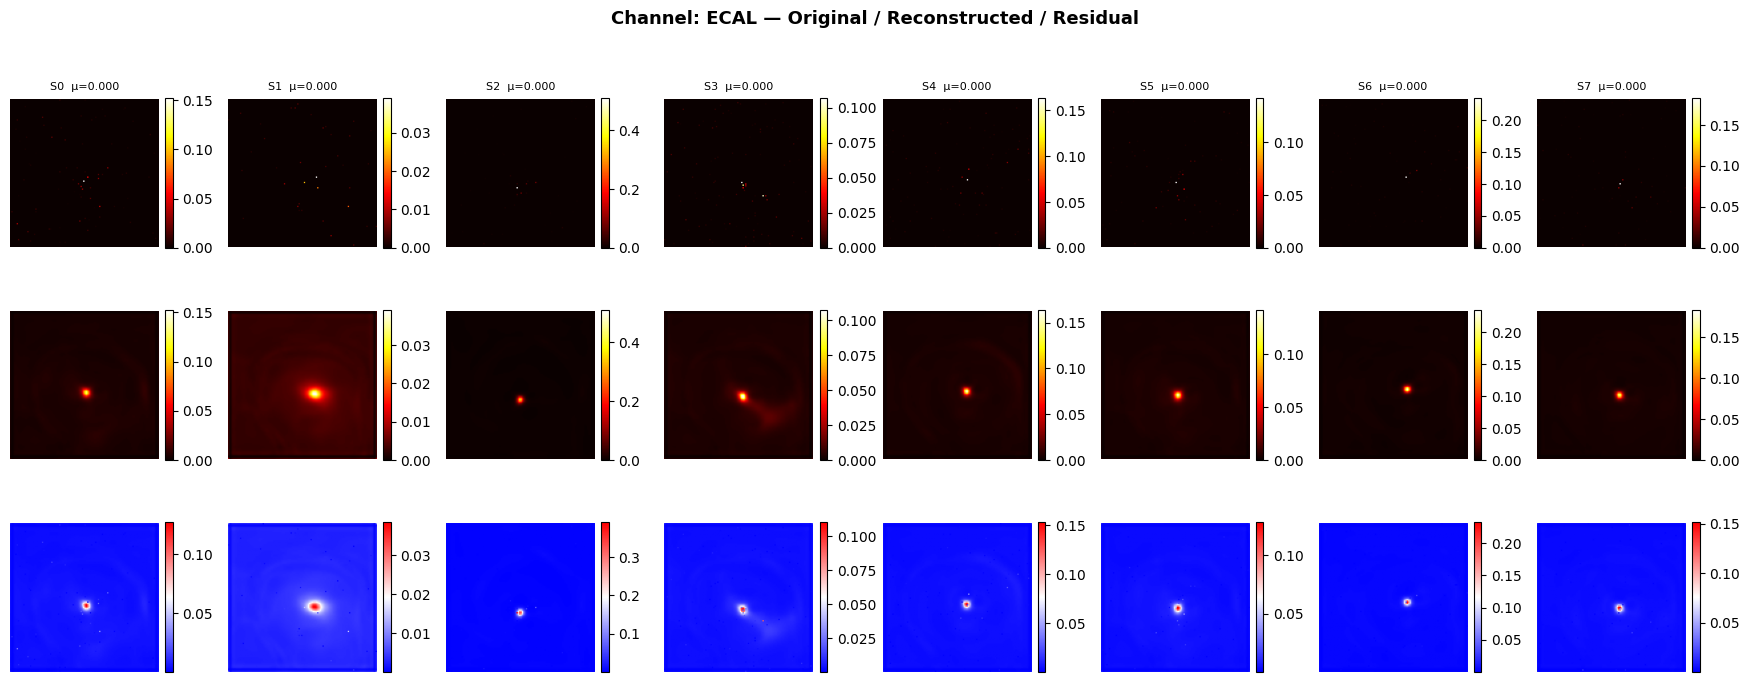

[ECAL] Mean abs residual: 0.0036


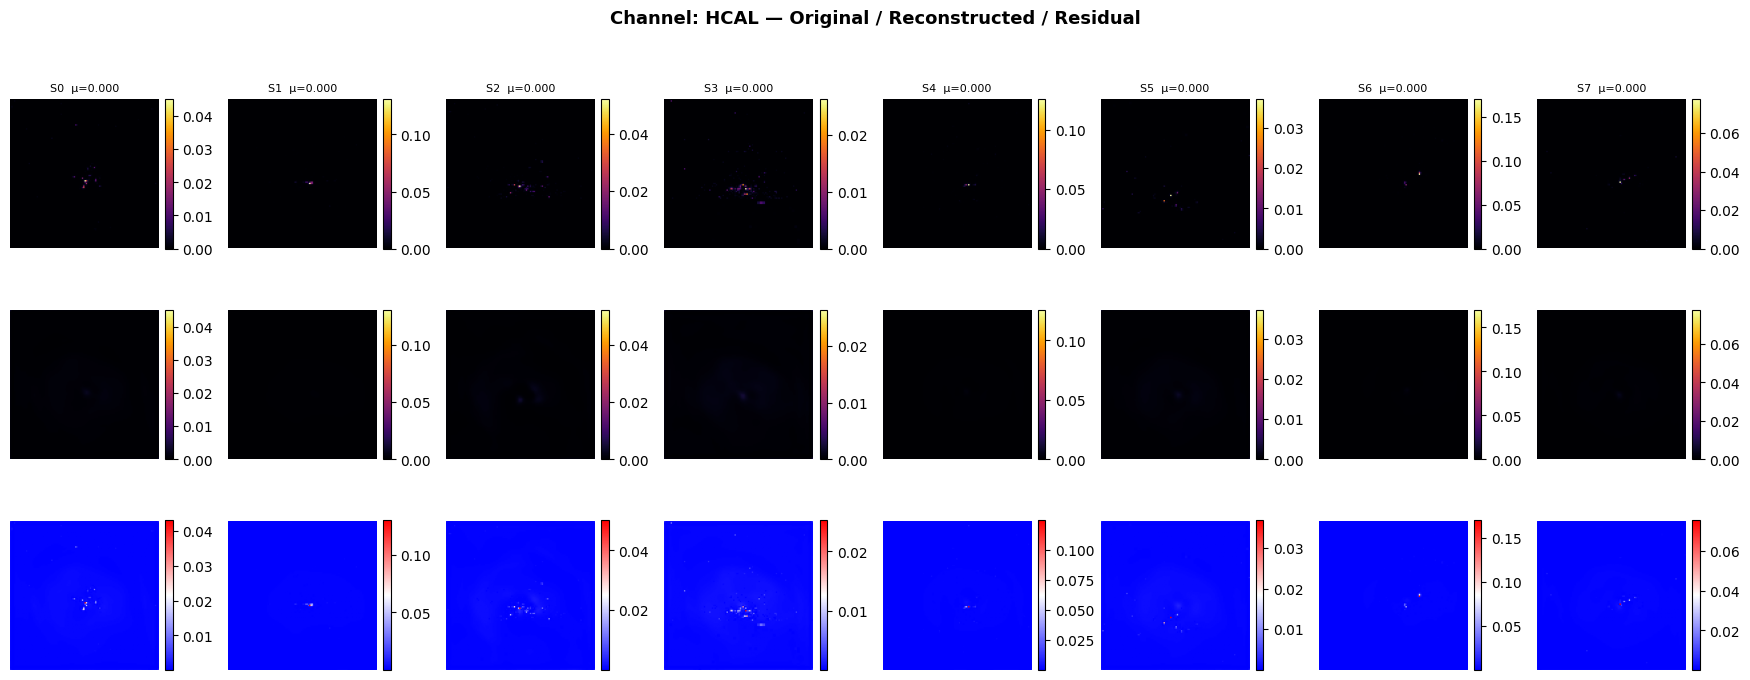

[HCAL] Mean abs residual: 0.0004


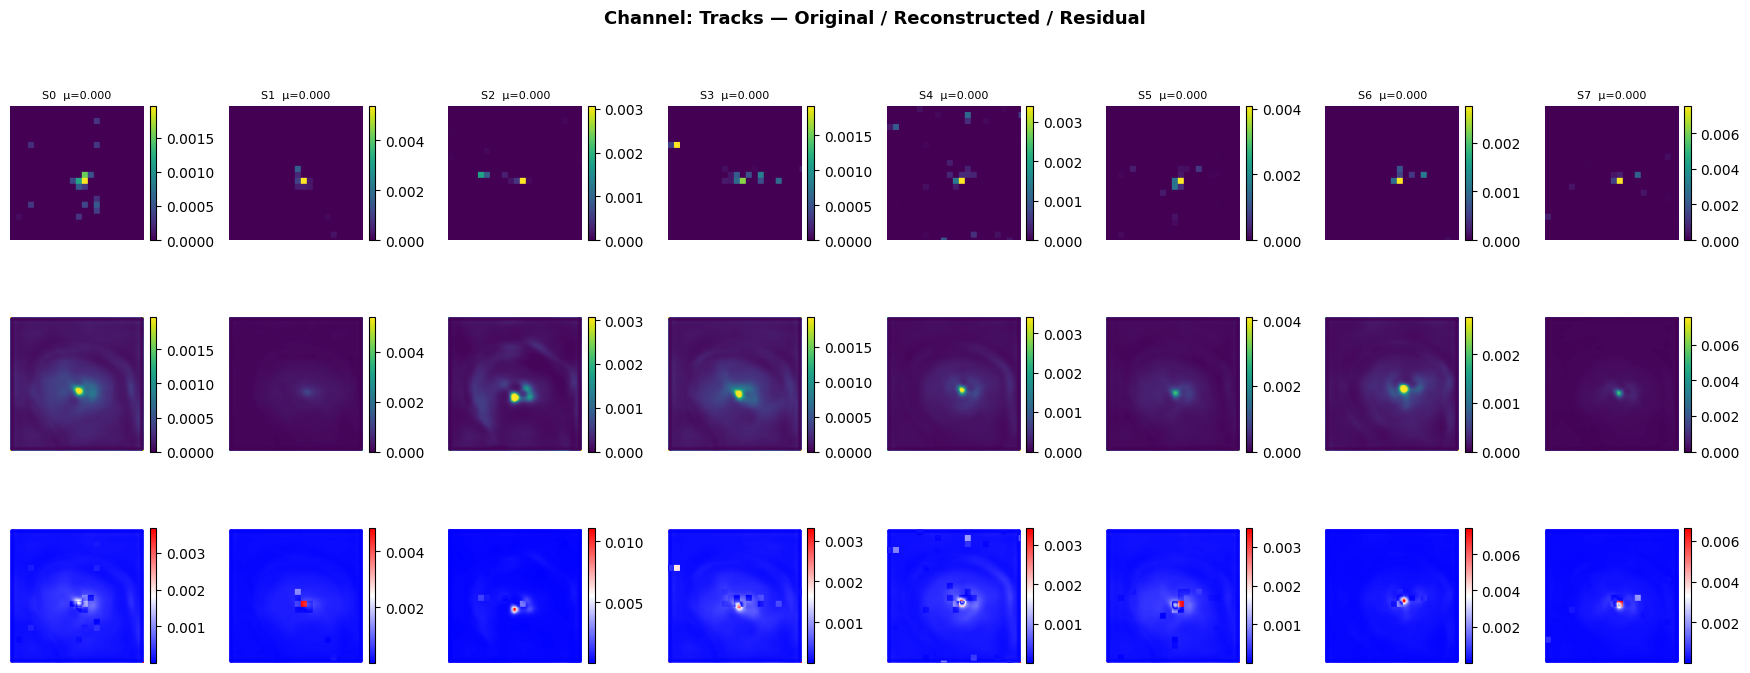

[Tracks] Mean abs residual: 0.0002


In [65]:

channel_cmaps  = ['hot', 'inferno', 'viridis']
N_SAMPLES = 8

model.eval()
samples = torch.stack([val_dataset[i] for i in range(N_SAMPLES)]).to(device)
with torch.no_grad():
    recons, _ = model(samples)

samples_np = samples.cpu().numpy()   # (N, 3, 112, 112)
recons_np  = recons.cpu().numpy()

for ch_idx, (ch_name, cmap) in enumerate(zip(channel_names, channel_cmaps)):

    fig, axes = plt.subplots(3, N_SAMPLES, figsize=(N_SAMPLES * 2.2, 7))
    fig.suptitle(f'Channel: {ch_name} — Original / Reconstructed / Residual',
                 fontsize=13, fontweight='bold', y=1.01)

    row_labels = ['Original', 'Reconstructed', 'Residual (|orig − recon|)']

    for col in range(N_SAMPLES):
        orig  = samples_np[col, ch_idx]   # (112, 112)
        recon = recons_np[col,  ch_idx]
        diff  = np.abs(orig - recon)

        vmin, vmax = orig.min(), orig.max()   # keep scale consistent per sample

        for row, (img, label) in enumerate(zip([orig, recon, diff], row_labels)):
            ax = axes[row, col]
            im = ax.imshow(img, cmap=cmap if row < 2 else 'bwr',
                           vmin=vmin if row < 2 else None,
                           vmax=vmax if row < 2 else None)
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(label, fontsize=9, rotation=90, labelpad=4)
            if row == 0:
                mean_e = orig.mean()
                ax.set_title(f'S{col}  μ={mean_e:.3f}', fontsize=8)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(f'reconstruction_{ch_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[{ch_name}] Mean abs residual: {np.abs(samples_np[:, ch_idx] - recons_np[:, ch_idx]).mean():.4f}")

## 12. Latent Space Analysis

We extract the 64-dimensional latent vectors from both models for all 4,000 validation samples, then reduce to 2D using PCA and t-SNE for visualisation.

**Important:** For the VAE we use `μ` (the mean of the posterior), not the sampled `z`. Using `z` would add stochastic noise that blurs the latent structure — `μ` is the true deterministic learned representation.

**What to look for:**
- **AE:** Likely scattered, unstructured — the AE has no incentive to organise the latent space
- **VAE:** Tighter, more Gaussian — the KL term explicitly forces structure
- **Quark/gluon separation:** Neither model was trained with labels, so any separation is genuinely learned from jet topology alone

In [66]:
# ── AE latent extraction ──────────────────────────────────────────────────────
model.eval()
ae_latents = []

with torch.no_grad():
    for batch in val_loader:
        _, z = model(batch.to(device))
        ae_latents.append(z.cpu())

ae_latents = torch.cat(ae_latents).numpy()
print("AE  latent shape:", ae_latents.shape)

# ── VAE latent extraction (use mu, not z) ─────────────────────────────────────
vae_model.eval()
vae_latents = []

with torch.no_grad():
    for batch in val_loader:
        _, z, mu, _ = vae_model(batch.to(device))
        vae_latents.append(mu.cpu())   # use mu — deterministic, no sampling noise

vae_latents = torch.cat(vae_latents).numpy()
print("VAE latent shape:", vae_latents.shape)

AE  latent shape: (4000, 64)
VAE latent shape: (4000, 64)


### 12a. PCA Projection
Linear 2D projection. The explained variance ratio tells us how much of the 64D structure is captured — a low ratio means the latent space is high-dimensional and PCA alone is insufficient.

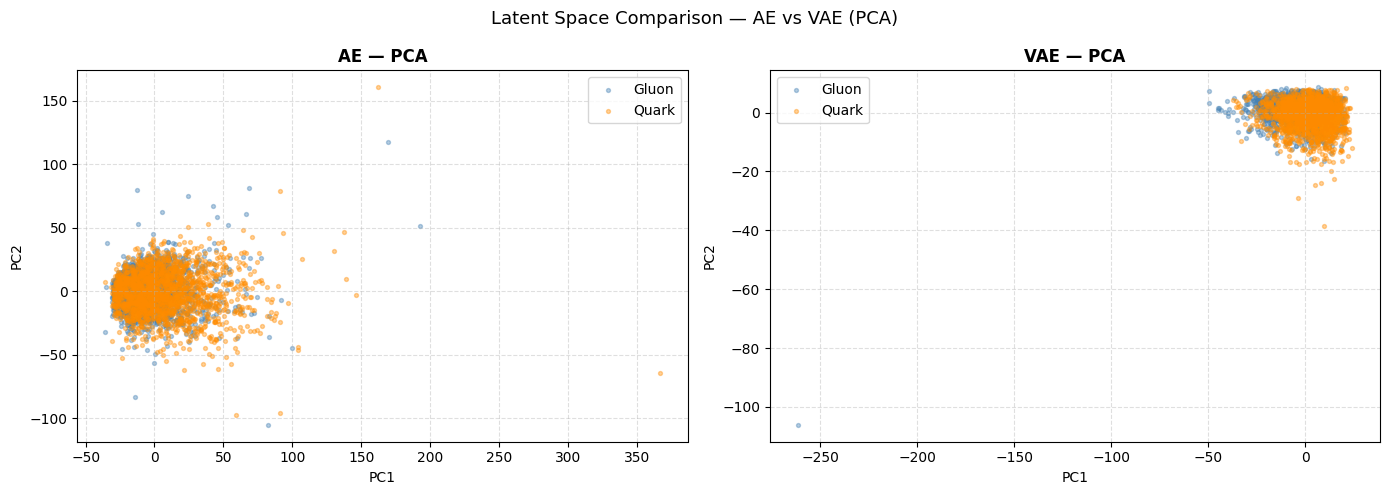

In [67]:
# ── PCA ───────────────────────────────────────────────────────────────────────
pca = PCA(n_components=2)
ae_pca  = pca.fit_transform(ae_latents)
vae_pca = pca.fit_transform(vae_latents)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, latent_2d, title in zip(axes, [ae_pca, vae_pca], ['AE — PCA', 'VAE — PCA']):
    ax.scatter(latent_2d[val_labels==0, 0], latent_2d[val_labels==0, 1],
               alpha=0.4, s=8, label='Gluon', color='steelblue')
    ax.scatter(latent_2d[val_labels==1, 0], latent_2d[val_labels==1, 1],
               alpha=0.4, s=8, label='Quark', color='darkorange')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend()
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle('Latent Space Comparison — AE vs VAE (PCA)', fontsize=13)
plt.tight_layout()
plt.savefig('latent_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 12b. t-SNE Projection
Non-linear 2D embedding. t-SNE preserves local neighbourhood structure better than PCA for complex manifolds. `perplexity=30` and `n_iter=500` are used for a balance of quality and speed.

Compare the AE and VAE side by side — the VAE latent space should show tighter, more isotropic clusters due to the KL regularisation.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


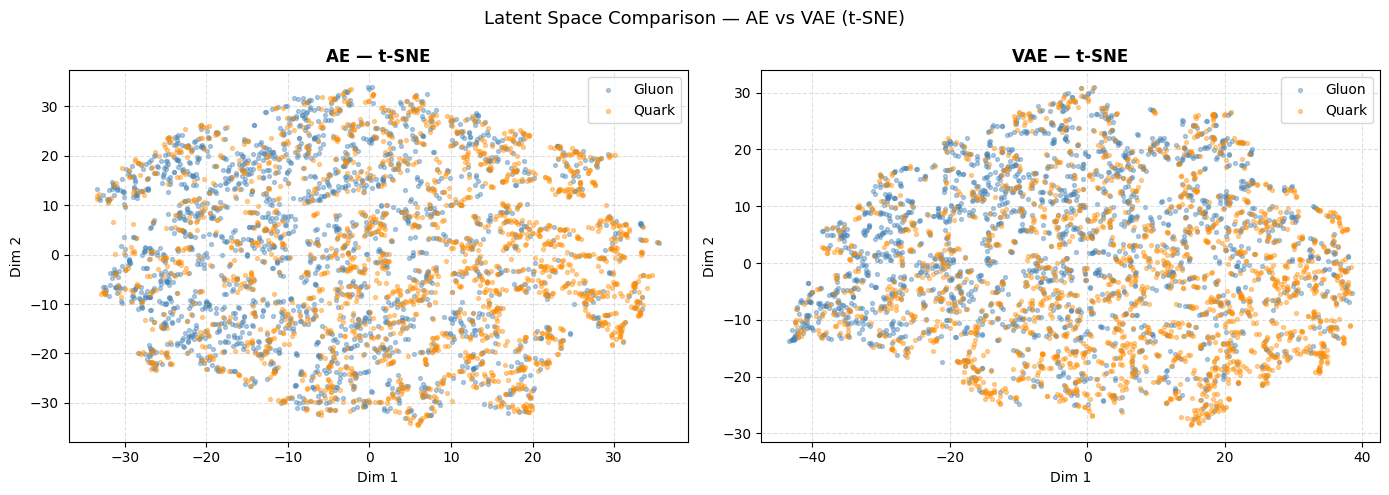

In [68]:
ae_tsne  = TSNE(n_components=2, perplexity=30, n_iter=500,
                random_state=42).fit_transform(ae_latents)
vae_tsne = TSNE(n_components=2, perplexity=30, n_iter=500,
                random_state=42).fit_transform(vae_latents)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, latent_2d, title in zip(axes, [ae_tsne, vae_tsne], ['AE — t-SNE', 'VAE — t-SNE']):
    ax.scatter(latent_2d[val_labels==0, 0], latent_2d[val_labels==0, 1],
               alpha=0.4, s=8, label='Gluon', color='steelblue')
    ax.scatter(latent_2d[val_labels==1, 0], latent_2d[val_labels==1, 1],
               alpha=0.4, s=8, label='Quark', color='darkorange')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.legend()
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle('Latent Space Comparison — AE vs VAE (t-SNE)', fontsize=13)
plt.tight_layout()
plt.savefig('latent_tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 13a. Reconstruction Quality

Both models successfully learn to reconstruct jet events in an unsupervised manner.
The AE and VAE exhibit a clear tradeoff that aligns with theoretical expectations:

**AE** optimises purely for reconstruction — with no regularisation on the latent 
space, all model capacity is directed toward minimising the weighted L1 loss. This 
produces sharper, more accurate pixel-level reconstructions, reflected in higher 
PSNR and SSIM scores.

**VAE** trades some reconstruction sharpness for a structured latent space. The KL 
divergence term forces the posterior toward $\mathcal{N}(0, I)$, which slightly 
blurs fine-grained features but produces a smoother, more continuous representation.

**Per-channel reconstruction difficulty** reveals an important distinction between 
theoretical sparsity and empirical learnability:

| Channel | Amplitude | Sparsity | Empirical Reconstruction | Reason |
|---------|-----------|----------|--------------------------|--------|
| Tracks | Medium–High | Low | Best | Structured spatial blobs, strong gradient signal |
| ECAL | High | Very High | Moderate | Isolated single pixels, but high amplitude makes deposits visible to the loss |
| HCAL | Very Low | High | Hardest | Low amplitude deposits (~0.01–0.04) drown in background even with 200× weighting |

**HCAL is empirically the hardest channel to reconstruct**, despite not being the 
most sparse. The critical factor is amplitude — HCAL deposits are so low in intensity 
that the weighted L1 loss, even with a 200× non-zero penalty, cannot generate 
sufficient gradient signal to force the decoder to recover them. The model learns 
that outputting near-zero everywhere incurs a lower total loss than attempting to 
localise sub-threshold deposits.

**ECAL**, despite being theoretically harder (more isolated, higher sparsity), 
reconstructs more visibly because its non-zero pixels reach amplitudes of ~0.15 — 
high enough that the 500× weight generates meaningful gradients. The decoder learns 
to place a soft blob at roughly the correct location, which is visually apparent 
against the black background.

This behaviour is confirmed by the residual maps:
- **ECAL residuals:** White ring localised around the deposit — model finds the right 
  region but slightly over-spreads spatially
- **HCAL residuals:** Uniformly near-zero across the image — the model outputs black 
  everywhere, which happens to have low absolute error because the targets are also 
  near-zero. This is a form of **trivial solution**, not successful reconstruction.

---

### 13b. Latent Space Structure

The latent space analysis reveals a key qualitative difference between the two models:

- The **AE latent space** is unstructured — points are scattered without geometric 
organisation, as the encoder has no incentive to produce any particular distribution

- The **VAE latent space** is visibly more compact and isotropic — the KL term 
explicitly regularises the distribution toward a unit Gaussian, producing tighter 
and more separable clusters

Notably, **partial quark/gluon separation emerges in both models despite training 
being entirely unsupervised** — labels were never used during training. This suggests 
both architectures capture genuine physical differences in jet topology between quark 
and gluon initiated jets, such as differences in particle multiplicity, energy spread, 
and track density.

---

### 13c. Model Comparison

| Criterion | AE | VAE |
|---|---|---|
| Reconstruction (MSE ↓) | Lower | Higher |
| Reconstruction (SSIM ↑) | Higher | Lower |
| Latent space structure | Unorganised | Smooth, Gaussian |
| Quark/gluon separation | Partial | Cleaner |
| Generative capability | None | Can sample new jets |
| Training stability | Simple | Requires KL annealing |

---

### 13d. Limitations & Future Work

- **HCAL trivial solution:** The current weighted L1 loss is insufficient for 
  ultra-low amplitude channels. Future work should explore a false-positive penalty 
  term that explicitly discourages outputting energy where none exists, or an 
  adversarial discriminator that evaluates deposit realism rather than pixel-level error.

- **Dataset size:** Only 20,000 of 139,306 events were used due to memory constraints. 
  Training on the full dataset would likely improve reconstruction of sparse channels 
  by exposing the model to a wider variety of deposit patterns.

- **Point cloud representations:** ECAL and HCAL are fundamentally ill-suited to 
  image-based CNNs due to their isolated, sparse deposits. Representing each non-zero 
  pixel as a particle hit with (x, y, energy) coordinates and using a graph neural 
  network or point cloud autoencoder would better exploit the physical structure of 
  these channels.

- **Latent space classification:** The partial quark/gluon separation observed here 
  provides a strong motivation for Task 2 — using these learned representations as 
  input features for a downstream classifier.